# 03 · Optimizacion global de asignacion y secuenciacion — LineWise DAMM

## Formulacion del problema

Dado un conjunto de SKUs a producir durante una semana, con volumen total en HL fijo por SKU,
resolver simultaneamente dos decisiones:

- **Asignacion**: que linea produce cada SKU.
- **Secuencia**: en que orden cronologico se produce cada SKU dentro de su linea.

La OF/MES es el nexo operativo: el coste de cada arco `SKU_origen -> SKU_destino` sale del post-mortem, donde cada cambio se interpreta revisando la OF anterior. La capacidad usa produccion (`HL / throughput`) mas **tiempo de cambio teorico**, coherente con la tabla de cambio de formato.

### Variables de decision

- `y[l,i]`: 1 si la linea `l` produce el SKU `i`.
- `x[l,i,j]`: 1 si en la linea `l` el SKU `i` va inmediatamente antes que `j`.
- `u[l,i]`: posicion del SKU `i` en la secuencia de la linea `l` (MTZ / prioridades).

### Funcion objetivo

Minimizar la degradacion total de OEE aprendida del historico:

$$\min \sum_{l,i,j} x[l,i,j] \cdot cost[l,i,j]$$

### Restricciones clave

1. Asignacion unica de cada SKU.
2. Conservacion de flujo con inicio/fin virtual por linea y eliminacion de subtours via MTZ.
3. Incompatibilidad estricta: SKUs que contienen `12` no pueden ir a L14 ni L17.
4. Capacidad semanal por linea.
5. Urgencias: asignacion forzada y posicion temprana (`u <= 2`).

### Solver

Google OR-Tools CP-SAT con `max_time_in_seconds = 60.0`. Se proporciona un hint heuristico factible solo para arrancar la busqueda; la solucion final la decide CP-SAT.


## 0 · Modelo de datos operativo: OF/MES como nexo

Este notebook sigue la arquitectura de datos de planta: la OF/MES es el nexo entre cambios, OEE, volumen y tiempos. La lectura operativa clave es que un cambio no vive aislado: para clasificarlo y medir su efecto hay que revisar la OF anterior en la misma linea y ventana temporal.

```mermaid
flowchart LR
    CF["Cambio formato"] -.-> TCT["Tiempo cambio teorico"]
    ML["Mantenimiento y limpiezas"] -.-> TCT
    TCT <--> OF["MES / OF (nexo)"]
    CAM["Cambios"] -.-> OF
    CAM --> TC["Tipo de cambio"]
    TC --> PREV["Revisar OF anterior"]
    OF -.-> OEE["OEE"]
    OF -.-> T["Tiempo"]
    OF -.-> V["Volumen"]
    OEE --> CYN["Cambio si/no"]
    OEE --> KPI["%OEE / %Rendimiento"]
    V --> V2["HL / UDS / OEE"]
    T --> T2["H Tot / Par Tot / PNP / Limpieza / Idle / %Disp / %Calidad / %Rend"]
```

Formulas usadas como control semantico:

- `OEE = Disponibilidad x Rendimiento x Calidad`
- `Disponibilidad = Tiempo funcionamiento / Tiempo planificado`
- `Rendimiento = (Tiempo ciclo ideal x Produccion total) / Tiempo funcionamiento`
- `Calidad = Produccion buena / Produccion total`
- `Tiempo cambio = H Tot - (PNP + Limpieza + Idle)`; `Idle` se separa para no imputarlo automaticamente al OEE.

En optimizacion, la matriz `Line/SKU_origen/SKU_destino` sale de revisar la OF anterior y entra como coste de `x[l,i,j]`.


In [11]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from typing import List, Tuple, Dict, Optional

from post_mortem import PostMortemAnalyzer
from data_loaders import (
    load_all_operations,
    load_diario_hl,
    weekly_demand_from_diario,
)
from scheduling_cp_sat import (
    DEFAULT_SETUP_HOURS,
    DEFAULT_MINOR_CHANGEOVER_HOURS,
    SCALE,
    build_cost_matrix,
    build_theoretical_changeover_matrix,
    estimate_hours,
    prepare_throughput,
    run_cpsat_global_mtz,
    run_fallback_heuristic,
    sequence_cost,
)

sns.set_theme(style='whitegrid', font_scale=1.1)
DATA_DIR = Path('../raw_data')

# Horas disponibles por semana por línea (3 turnos x 5 dias laborables x 8h = 120h,
# menos tiempos de limpieza y mantenimiento estimados)
HOURS_PER_WEEK = {'14': 110, '17': 115, '19': 115}
print("Configuracion de capacidad semanal:", HOURS_PER_WEEK, "horas/linea")
print(f"Escalado CP-SAT: SCALE={SCALE:,} | setup teorico menor={DEFAULT_MINOR_CHANGEOVER_HOURS:.1f}h | fallback formato={DEFAULT_SETUP_HOURS:.1f}h")


Configuracion de capacidad semanal: {'14': 110, '17': 115, '19': 115} horas/linea
Escalado CP-SAT: SCALE=1,000 | setup teorico menor=1.0h | fallback formato=3.5h


## 1 · Cargar datos y ejecutar pipeline post-mortem

In [12]:
dfs = load_all_operations(DATA_DIR)
print(f"OEE: {len(dfs['oee'])} OFs | tren unicos: {sorted(dfs['oee']['tren'].dropna().unique())}")

analyzer = PostMortemAnalyzer(
    df_oee=dfs['oee'], df_cambios=dfs['cam'], df_mantenimiento=dfs['mant'],
    df_tiempo=dfs['tiem'], df_volumen=dfs['vol'],
)
metrics = analyzer.run_full_pipeline()
matrices = analyzer.build_transition_matrices()
print("\nPipeline post-mortem completado")

OEE: 2141 OFs | tren unicos: ['14', '17', '19']
  PostMortemAnalyzer — Pipeline completo
[clean_and_isolate_maintenance] OFs contaminadas (>20%): 293/2141 (13.7%)
  → imputadas por mediana SKU-línea (>50%): 105
[build_transition_matrices] Línea 14: 236 transiciones únicas (59 nodos origen, 60 nodos destino)
[build_transition_matrices] Línea 17: 567 transiciones únicas (94 nodos origen, 93 nodos destino)
[build_transition_matrices] Línea 19: 555 transiciones únicas (115 nodos origen, 113 nodos destino)
[build_directed_graph] Línea 14: 63 nodos, 236 aristas
[build_directed_graph] Línea 17: 94 nodos, 567 aristas
[build_directed_graph] Línea 19: 117 nodos, 555 aristas
[detect_black_spots] 21 black spots detectados (umbral degradación > μ + 1.5σ, mín. 2 ocurrencias)
[export_explainability_metrics] Métricas de explicabilidad generadas:
  · top_black_spots: 10 filas
  · critical_nodes: 20 filas
  · weekly_oee_loss: 152 filas
  · line_summary: 3 filas
[build_transition_matrices] Línea 14: 236 

## 2 · Cargar demanda de la semana test (Diario Hl_Planif)

In [13]:
df_diario = load_diario_hl(DATA_DIR / 'Diario Hl_Planif.xlsx')
assert not df_diario['sku'].str.lower().str.contains('total', na=False).any(), \
    "El Diario contiene filas TOTAL mal parseadas como SKU"

demanda_semanal = weekly_demand_from_diario(df_diario)

print(f"Demanda semanal - {df_diario['fecha'].min().date()} al {df_diario['fecha'].max().date()}")
print(f"  SKUs unicos: {demanda_semanal['sku'].nunique()}  |  HL total: {demanda_semanal['hl_total'].sum():,.0f}")
print()
print("Carga original por linea (antes de optimizar):")
print(df_diario.groupby('tren').agg(n_skus=('sku','nunique'), hl=('hl_planificado','sum')).round(0))
print()
print(demanda_semanal.to_string(index=False))

Demanda semanal - 2026-05-18 al 2026-05-21
  SKUs unicos: 28  |  HL total: 36,933

Carga original por linea (antes de optimizar):
      n_skus       hl
tren                 
14         3   7441.0
17        13  14391.0
19        13  15102.0

tren      sku    hl_total original_tren  row_order first_fecha
  14 ED13LP24 5591.519958         14,17          0  2026-05-18
  14  FDT13LT 1671.120026            14          5  2026-05-18
  14 VO13LTNN  574.200012            14          7  2026-05-21
  17   DL13LT 3117.870117            17          8  2026-05-19
  17 FD13LTNN 1393.919983            17         10  2026-05-18
  17  FDL13LN  720.719971            17         12  2026-05-19
  17 KE13LTNN  625.680008            17         13  2026-05-20
  17 KE13PL12  293.040009            17         15  2026-05-21
  17 LC13LTNN 1789.919922            17         16  2026-05-21
  17   SK13LN 1927.170044            17         17  2026-05-21
  17  TU13LTN 1425.599976            17         18  2026-05-20
  1

## 3 · Construir matriz de costes de secuenciación

In [14]:
# Matrices de coste OEE y tiempos auxiliares compartidos por CP-SAT y fallback.
throughput = prepare_throughput(dfs)

all_skus_week = demanda_semanal['sku'].tolist()

# SOBREESCRIBIR matrices usando el modelo de grafos suavizado bilinear
matrices = analyzer.build_transition_matrices()
PRIORITY_ORDERS = [] # Definir para evitar NameError en celdas posteriores
print("Matrices de coste, changeover y throughput preparadas")
print("\nThroughput mediano por linea (HL/h):")
print(throughput.groupby('tren')['hl_per_h'].median().round(1))
print("\nCobertura historica de costes para la semana test:")
for line in ['14', '17', '19']:
    mat = build_cost_matrix(line, all_skus_week, matrices)
    co = build_theoretical_changeover_matrix(line, all_skus_week)
    offdiag = len(all_skus_week) * (len(all_skus_week) - 1)
    hist = 0
    if line in matrices:
        raw = matrices[line]['oee_degradation']
        for origin in all_skus_week:
            for dest in all_skus_week:
                if origin != dest and origin in raw.index and dest in raw.columns and pd.notna(raw.loc[origin, dest]):
                    hist += 1
    print(f"  L{line}: coste {mat.shape[0]}x{mat.shape[1]} | historico {hist}/{offdiag} | "
          f"changeover teorico mediana {co.replace(0, np.nan).stack().median():.2f}h")


[build_transition_matrices] Línea 14: 236 transiciones únicas (59 nodos origen, 60 nodos destino)
[build_transition_matrices] Línea 17: 567 transiciones únicas (94 nodos origen, 93 nodos destino)
[build_transition_matrices] Línea 19: 555 transiciones únicas (115 nodos origen, 113 nodos destino)
Matrices de coste, changeover y throughput preparadas

Throughput mediano por linea (HL/h):
tren
14     82.4
17    144.2
19    140.5
Name: hl_per_h, dtype: float64

Cobertura historica de costes para la semana test:
  L14: coste 28x28 | historico 0/756 | changeover teorico mediana 1.00h
  L17: coste 28x28 | historico 0/756 | changeover teorico mediana 1.00h
  L19: coste 28x28 | historico 0/756 | changeover teorico mediana 1.00h


## 4 · Utilidades de coste, throughput y arranque heuristico

In [15]:
# Las funciones de secuenciacion y estimacion horaria viven en scheduling_cp_sat.py.
# Se mantienen importadas para que las celdas posteriores y el jurado puedan inspeccionarlas.
print("Funciones de optimizacion importadas desde scheduling_cp_sat")


Funciones de optimizacion importadas desde scheduling_cp_sat


## 5.1 · Modelo CP-SAT exacto: asignacion + secuencia

El modelo usa la lectura del diagrama de planta:

- `y[l,i]`: asigna cada SKU/OF planificada a una unica linea.
- `x[l,i,j]`: activa una transicion inmediata y, por tanto, aplica el coste aprendido de revisar la OF anterior.
- `u[l,i]`: posicion en la ruta de la linea para eliminar subtours y forzar urgencias tempranas.
- Capacidad: produccion (`HL / throughput`) + tiempo de cambio entre OFs consecutivas.


In [16]:
# Modelo exacto global: asignacion + secuenciacion simultaneas con CP-SAT y MTZ.
# Si OR-Tools no esta instalado, se conserva un fallback heuristico local para que
# el notebook siga siendo ejecutable, pero la solucion entregable es CP-SAT.

results = run_cpsat_global_mtz(
    demanda_semanal=demanda_semanal,
    matrices=matrices,
    throughput=throughput,
    hours_per_week=HOURS_PER_WEEK,
    priority_orders=PRIORITY_ORDERS,
    setup_hours=DEFAULT_SETUP_HOURS,
    time_limit=60.0,
    log_search_progress=False,
)

if results is None:
    print("\nFallback heuristico por linea: OR-Tools no disponible o CP-SAT sin solucion factible.")
    results = run_fallback_heuristic(
        demanda_semanal=demanda_semanal,
        matrices=matrices,
        throughput=throughput,
        hours_per_week=HOURS_PER_WEEK,
        priority_orders=PRIORITY_ORDERS,
        setup_hours=DEFAULT_SETUP_HOURS,
    )

schedule_df = results.get('_schedule_df', pd.DataFrame())
print("\nCarga optimizada por linea:")
summary_rows = []
for line in ['14', '17', '19']:
    if line not in results:
        continue
    r = results[line]
    summary_rows.append({
        'linea': line,
        'skus': len(r['seq_optimized']),
        'prod_h': r['prod_hours_estimated'],
        'setup_h': r['setup_hours_estimated'],
        'total_h': r['hours_estimated'],
        'capacidad_h': HOURS_PER_WEEK[line],
        'capacity_ok': r['capacity_ok'],
        'coste_oee': r['cost_optimized'],
    })
summary_cp = pd.DataFrame(summary_rows)
print(summary_cp.to_string(index=False, float_format='{:.2f}'.format))


Carga optimizada por linea:
linea  skus  prod_h  setup_h  total_h  capacidad_h  capacity_ok  coste_oee
   14     3   68.62     2.00    70.62          110         True       0.02
   17    12   83.96    11.00    94.96          115         True       0.01
   19    13   89.47    12.00   101.47          115         True       0.00


## 6 · Visualización: Gantt de secuencia optimizada vs. baseline

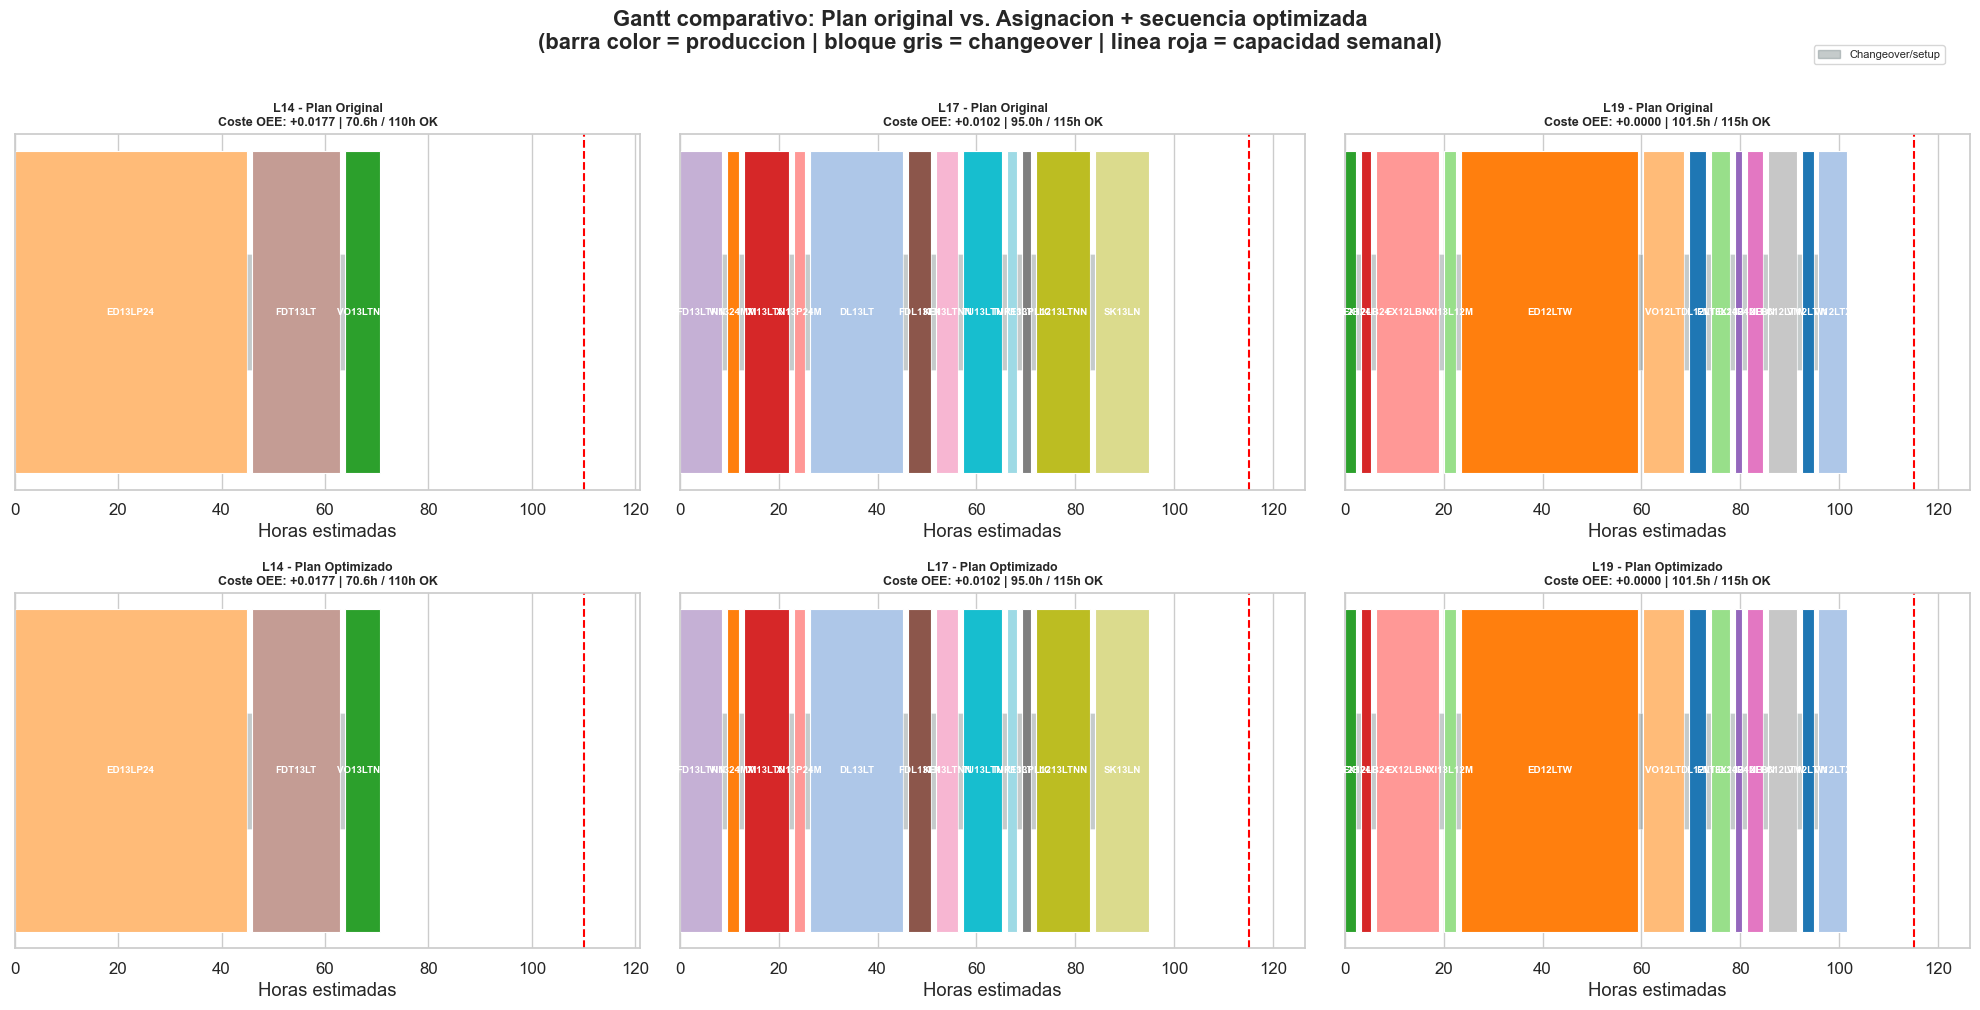

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
colors_sku = {}
all_skus = sorted(set(demanda_semanal['sku']).union(set(schedule_df['sku']) if not schedule_df.empty else set()))
palette = plt.cm.tab20.colors
for i, sku in enumerate(all_skus):
    colors_sku[sku] = palette[i % len(palette)]

for col, line in enumerate(['14', '17', '19']):
    if line not in results:
        continue
    res = results[line]

    panels = [
        ('baseline_details', 'Plan Original', res['cost_baseline'], res['baseline_hours_estimated']),
        ('details', 'Plan Optimizado', res['cost_optimized'], res['hours_estimated']),
    ]
    for row, (detail_key, label, cost_value, total_h) in enumerate(panels):
        ax = axes[row][col]
        det = res.get(detail_key, pd.DataFrame()).copy()
        if det.empty:
            ax.text(0.5, 0.5, 'Sin SKUs', ha='center', va='center', transform=ax.transAxes)
            ax.set_axis_off()
            continue

        for _, item in det.iterrows():
            setup_h = float(item.get('setup_h', 0.0))
            setup_start = float(item.get('setup_start_h', max(item['start_h'] - setup_h, 0)))
            if setup_h > 0:
                ax.barh(0, setup_h, left=setup_start, height=0.18,
                        color='#7f8c8d', alpha=0.45, edgecolor='white', linewidth=0.5)
            width = float(item['prod_h'])
            ax.barh(0, width, left=float(item['start_h']), height=0.5,
                    color=colors_sku.get(item['sku'], 'gray'), edgecolor='white', linewidth=0.8)
            if width > 1.5:
                ax.text(float(item['start_h']) + width / 2, 0, str(item['sku'])[:8],
                        ha='center', va='center', fontsize=7, fontweight='bold', color='white')

        cap = HOURS_PER_WEEK[line]
        ax.axvline(cap, color='red', linestyle='--', lw=1.5)
        ax.set_xlim(0, max(cap * 1.1, float(total_h) * 1.1, 1.0))
        ax.set_yticks([])
        ax.set_xlabel('Horas estimadas')
        cap_flag = 'OK' if float(total_h) <= cap + 1e-6 else 'EXCEDE'
        ax.set_title(
            f'L{line} - {label}\nCoste OEE: {cost_value:+.4f} | {total_h:.1f}h / {cap}h {cap_flag}',
            fontweight='bold', fontsize=9,
        )

setup_patch = mpatches.Patch(color='#7f8c8d', alpha=0.45, label='Changeover/setup')
fig.legend(handles=[setup_patch], loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=8)
plt.suptitle(
    'Gantt comparativo: Plan original vs. Asignacion + secuencia optimizada\n'
    '(barra color = produccion | bloque gris = changeover | linea roja = capacidad semanal)',
    fontweight='bold', y=1.01,
)
plt.tight_layout()
plt.show()

## 7 · Resumen de impacto y mejora estimada

In [18]:
print("=" * 72)
print("  RESUMEN DE OPTIMIZACION - Semana 18-24 Mayo 2026")
print("=" * 72)

bs_df = analyzer.detect_black_spots()
bs_ok = 'tren' in bs_df.columns and 'sku_prev' in bs_df.columns

for line in ['14', '17', '19']:
    if line not in results:
        continue
    r = results[line]
    cap = HOURS_PER_WEEK[line]
    cap_flag = 'OK' if r['capacity_ok'] else 'EXCEDE CAPACIDAD'

    print(f"\n{'-'*72}")
    print(f"  LINEA {line}")
    print(f"{'-'*72}")
    print(f"  Coste degradacion OEE original : {r['cost_baseline']:+.4f}")
    print(f"  Coste degradacion OEE optimiz. : {r['cost_optimized']:+.4f}")
    print(f"  Horas produccion/setup/total   : {r['prod_hours_estimated']:.1f}h / "
          f"{r['setup_hours_estimated']:.1f}h / {r['hours_estimated']:.1f}h")
    print(f"  Capacidad semanal              : {r['hours_estimated']:.1f}h / {cap}h  {cap_flag}")

    moved = []
    det = r['details']
    if not det.empty and 'original_tren' in det.columns:
        moved = det[~det['original_tren'].astype(str).str.split(',').apply(lambda xs: line in xs)]['sku'].tolist()
    if moved:
        print(f"  SKUs reasignados a L{line}: {', '.join(moved)}")

    print("\n  Secuencia recomendada:")
    seq = r['seq_optimized']
    for _, item in det.iterrows():
        i = int(item['sequence_order']) - 1
        sku = item['sku']
        if i < len(seq) - 1:
            nxt = seq[i + 1]
            deg = item.get('cost_to_next', np.nan)
            arrow = f"-> {nxt}  [deg: {deg:+.3f}]" if pd.notna(deg) else f"-> {nxt}"
        else:
            arrow = "(fin)"

        flags = []
        if item.get('priority_tipo'):
            flags.append(str(item['priority_tipo']).upper())
        if bs_ok:
            mask = (bs_df['tren'].astype(str) == line) & (bs_df['sku_prev'] == sku)
            if mask.any():
                flags.append('BLACK SPOT origen')
        flag_txt = f"  [{' | '.join(flags)}]" if flags else ""

        print(f"    {int(item['sequence_order']):2d}. {sku:<30} "
              f"{item['hl']:>7.0f} HL  prod {item['prod_h']:>5.1f}h  "
              f"setup {item['setup_h']:>4.1f}h  {arrow}{flag_txt}")

print(f"\n{'-'*72}")
print("Interpretacion: coste OEE positivo = degradacion esperada; coste negativo = mejora historica neta.")
print("Las filas grises del Gantt representan changeovers incluidos en la restriccion de capacidad.")

  RESUMEN DE OPTIMIZACION - Semana 18-24 Mayo 2026
[detect_black_spots] 21 black spots detectados (umbral degradación > μ + 1.5σ, mín. 2 ocurrencias)

------------------------------------------------------------------------
  LINEA 14
------------------------------------------------------------------------
  Coste degradacion OEE original : +0.0177
  Coste degradacion OEE optimiz. : +0.0177
  Horas produccion/setup/total   : 68.6h / 2.0h / 70.6h
  Capacidad semanal              : 70.6h / 110h  OK

  Secuencia recomendada:
     1. ED13LP24                          5592 HL  prod  44.8h  setup  0.0h  -> FDT13LT  [deg: +1.000]
     2. FDT13LT                           1671 HL  prod  17.0h  setup  1.0h  -> VO13LTNN  [deg: +1.000]
     3. VO13LTNN                           574 HL  prod   6.8h  setup  1.0h  (fin)

------------------------------------------------------------------------
  LINEA 17
------------------------------------------------------------------------
  Coste degradacion OEE 

In [19]:
# Tabla detallada de la secuencia optimizada de L17 y vista global auditable.
if '17' in results:
    print("\nDetalle secuencia optimizada Linea 17:")
    det = results['17']['details'].copy()
    cols = [
        'sequence_order', 'sku', 'original_tren', 'hl', 'throughput_hl_h',
        'setup_h', 'prod_h', 'start_h', 'end_h', 'priority_tipo', 'cost_to_next'
    ]
    cols = [c for c in cols if c in det.columns]
    print(det[cols].to_string(index=False, float_format='{:.2f}'.format))

if not schedule_df.empty:
    print("\nSchedule optimizado global:")
    cols = ['line', 'sequence_order', 'sku', 'original_tren', 'hl', 'setup_h', 'prod_h', 'start_h', 'end_h']
    print(schedule_df[cols].sort_values(['line', 'sequence_order']).to_string(index=False, float_format='{:.2f}'.format))


Detalle secuencia optimizada Linea 17:
 sequence_order      sku original_tren      hl  setup_h  prod_h  start_h  end_h priority_tipo  cost_to_next
              1 FD13LTNN            17 1393.92     0.00    8.58     0.00   8.58                        1.00
              2 VI1324MM            17  356.40     1.00    2.42     9.58  12.00                        1.00
              3  XI13LTN            17 1631.52     1.00    9.03    13.00  22.03                        1.00
              4 XI13P24M            17  396.00     1.00    2.28    23.03  25.31                        1.00
              5   DL13LT            17 3117.87     1.00   18.82    26.31  45.13                        1.00
              6  FDL13LN            17  720.72     1.00    4.71    46.13  50.84                        1.00
              7 KE13LTNN            17  625.68     1.00    4.34    51.84  56.18                        1.00
              8  TU13LTN            17 1425.60     1.00    8.02    57.18  65.20                 